# Preprocess0

Początek preprocessingu. Pobranie danych oraz wytworzenie pliku labels

## 0. Data preparation

In [1]:
import pandas as pd

import seaborn as sns

import os
import numpy as np
import librosa
from pydub import AudioSegment

import os, io, random, warnings
import pandas as pd
from contextlib import redirect_stderr

In [2]:
tracks = pd.read_csv('/Users/pawelmozaryn/MACHINE_LEARNING/Nonlinear_and_ml/fma_tracks/fma_metadata/tracks.csv')

/var/folders/5c/hllqzkms2wqg51r_sh4t_dm80000gn/T/ipykernel_42080/3479187674.py:1: DtypeWarning: Columns (0,1,5,6,8,12,18,20,21,22,24,33,34,38,39,44,47,49) have mixed types. Specify dtype option on import or set low_memory=False.
  tracks = pd.read_csv('/Users/pawelmozaryn/MACHINE_LEARNING/Nonlinear_and_ml/fma_tracks/fma_metadata/tracks.csv')


In [3]:
tracks

,Unnamed: 0,album,album.1,album.2,album.3,album.4,album.5,album.6,album.7,album.8,...,track.10,track.11,track.12,track.13,track.14,track.15,track.16,track.17,track.18,track.19
0,NaN,comments,date_created,date_released,engineer,favorites,id,information,listens,producer,...,information,interest,language_code,license,listens,lyricist,number,publisher,tags,title
1,track_id,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,0,2008-11-26 01:44:45,2009-01-05 00:00:00,NaN,4,1,<p></p>,6073,NaN,...,NaN,4656,en,Attribution-NonCommercial-ShareAlike 3.0 Inter...,1293,NaN,3,NaN,[],Food
3,3,0,2008-11-26 01:44:45,2009-01-05 00:00:00,NaN,4,1,<p></p>,6073,NaN,...,NaN,1470,en,Attribution-NonCommercial-ShareAlike 3.0 Inter...,514,NaN,4,NaN,[],Electric Ave
4,5,0,2008-11-26 01:44:45,2009-01-05 00:00:00,NaN,4,1,<p></p>,6073,NaN,...,NaN,1933,en,Attribution-NonCommercial-ShareAlike 3.0 Inter...,1151,NaN,6,NaN,[],This World
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106571,155316,0,2017-03-30 15:20:35,2017-02-17 00:00:00,NaN,0,22940,"<p>A live performance at Monty Hall on Feb 17,...",1506,Monty Hall,...,NaN,122,NaN,Creative Commons Attribution-NonCommercial-NoD...,102,NaN,3,NaN,[],The Auger
106572,155317,0,2017-03-30 15:20:35,2017-02-17 00:00:00,NaN,0,22940,"<p>A live performance at Monty Hall on Feb 17,...",1506,Monty Hall,...,NaN,194,NaN,Creative Commons Attribution-NonCommercial-NoD...,165,NaN,4,NaN,[],Let's Skin Ruby
106573,155318,0,2017-03-30 15:20:35,2017-02-17 00:00:00,NaN,0,22940,"<p>A live performance at Monty Hall on Feb 17,...",1506,Monty Hall,...,NaN,214,NaN,Creative Commons Attribution-NonCommercial-NoD...,168,NaN,6,NaN,[],My House Smells Like Kim Deal/Pulp
106574,155319,0,2017-03-30 15:20:35,2017-02-17 00:00:00,NaN,0,22940,"<p>A live performance at Monty Hall on Feb 17,...",1506,Monty Hall,...,NaN,336,NaN,Creative Commons Attribution-NonCommercial-NoD...,294,NaN,5,NaN,[],The Man With Two Mouths


In [4]:
## tworzę nagłówek z kolumnami

header1 = list(tracks.columns)
header2 = list(tracks.iloc[0])
header3 = list(tracks.iloc[1])
colnames = ['track_id'] + [str(header1[i]) + "_" + str(header2[i]) for i in range(len(header1))][1:]
colnames = [s.replace('.', '') for s in colnames]

In [5]:
colnames

['track_id',
 'album_comments',
 'album1_date_created',
 'album2_date_released',
 'album3_engineer',
 'album4_favorites',
 'album5_id',
 'album6_information',
 'album7_listens',
 'album8_producer',
 'album9_tags',
 'album10_title',
 'album11_tracks',
 'album12_type',
 'artist_active_year_begin',
 'artist1_active_year_end',
 'artist2_associated_labels',
 'artist3_bio',
 'artist4_comments',
 'artist5_date_created',
 'artist6_favorites',
 'artist7_id',
 'artist8_latitude',
 'artist9_location',
 'artist10_longitude',
 'artist11_members',
 'artist12_name',
 'artist13_related_projects',
 'artist14_tags',
 'artist15_website',
 'artist16_wikipedia_page',
 'set_split',
 'set1_subset',
 'track_bit_rate',
 'track1_comments',
 'track2_composer',
 'track3_date_created',
 'track4_date_recorded',
 'track5_duration',
 'track6_favorites',
 'track7_genre_top',
 'track8_genres',
 'track9_genres_all',
 'track10_information',
 'track11_interest',
 'track12_language_code',
 'track13_license',
 'track14_list

In [6]:
# dopiero od wiersza 2 zaczynają się właściwe dane piosenek 

tracks = tracks.iloc[2:]


# mój colnames
tracks.columns = colnames


# chcę, aby track_id było zawsze 6 cyfrowe
tracks["track_id"] = tracks["track_id"].astype(str).str.zfill(6)
tracks.to_csv('clean_metadata.csv', index = False)

/var/folders/5c/hllqzkms2wqg51r_sh4t_dm80000gn/T/ipykernel_42080/2365745854.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tracks["track_id"] = tracks["track_id"].astype(str).str.zfill(6)


In [7]:
tracks_clean = pd.read_csv('clean_metadata.csv',
                           dtype = {'track_id': str})

In [8]:
tracks_clean

,track_id,album_comments,album1_date_created,album2_date_released,album3_engineer,album4_favorites,album5_id,album6_information,album7_listens,album8_producer,...,track10_information,track11_interest,track12_language_code,track13_license,track14_listens,track15_lyricist,track16_number,track17_publisher,track18_tags,track19_title
0,000002,0,2008-11-26 01:44:45,2009-01-05 00:00:00,NaN,4,1,<p></p>,6073,NaN,...,NaN,4656,en,Attribution-NonCommercial-ShareAlike 3.0 Inter...,1293,NaN,3,NaN,[],Food
1,000003,0,2008-11-26 01:44:45,2009-01-05 00:00:00,NaN,4,1,<p></p>,6073,NaN,...,NaN,1470,en,Attribution-NonCommercial-ShareAlike 3.0 Inter...,514,NaN,4,NaN,[],Electric Ave
2,000005,0,2008-11-26 01:44:45,2009-01-05 00:00:00,NaN,4,1,<p></p>,6073,NaN,...,NaN,1933,en,Attribution-NonCommercial-ShareAlike 3.0 Inter...,1151,NaN,6,NaN,[],This World
3,000010,0,2008-11-26 01:45:08,2008-02-06 00:00:00,NaN,4,6,NaN,47632,NaN,...,NaN,54881,en,Attribution-NonCommercial-NoDerivatives (aka M...,50135,NaN,1,NaN,[],Freeway
4,000020,0,2008-11-26 01:45:05,2009-01-06 00:00:00,NaN,2,4,"<p> ""spiritual songs"" from Nicky Cook</p>",2710,NaN,...,NaN,978,en,Attribution-NonCommercial-NoDerivatives (aka M...,361,NaN,3,NaN,[],Spiritual Level
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106569,155316,0,2017-03-30 15:20:35,2017-02-17 00:00:00,NaN,0,22940,"<p>A live performance at Monty Hall on Feb 17,...",1506,Monty Hall,...,NaN,122,NaN,Creative Commons Attribution-NonCommercial-NoD...,102,NaN,3,NaN,[],The Auger
106570,155317,0,2017-03-30 15:20:35,2017-02-17 00:00:00,NaN,0,22940,"<p>A live performance at Monty Hall on Feb 17,...",1506,Monty Hall,...,NaN,194,NaN,Creative Commons Attribution-NonCommercial-NoD...,165,NaN,4,NaN,[],Let's Skin Ruby
106571,155318,0,2017-03-30 15:20:35,2017-02-17 00:00:00,NaN,0,22940,"<p>A live performance at Monty Hall on Feb 17,...",1506,Monty Hall,...,NaN,214,NaN,Creative Commons Attribution-NonCommercial-NoD...,168,NaN,6,NaN,[],My House Smells Like Kim Deal/Pulp
106572,155319,0,2017-03-30 15:20:35,2017-02-17 00:00:00,NaN,0,22940,"<p>A live performance at Monty Hall on Feb 17,...",1506,Monty Hall,...,NaN,336,NaN,Creative Commons Attribution-NonCommercial-NoD...,294,NaN,5,NaN,[],The Man With Two Mouths


In [9]:
# do pliku labels potrzebujemy tylko track_id oraz track7_genre_top
labels = tracks_clean[['track_id', 'track7_genre_top']]

# nazwy kolumn 
labels.columns = ['track_id', 'track_genre']

# zapisuję w csv
labels.to_csv('labels.csv', index = False)

In [18]:
#TODO

## poprawienie dataframe'a (nazwy kolumn z columns i pierwszego)

## merge tracków które mamy w tracks.csv oraz w fma_tracks

## przycięcie do 5 sekund

## dysk dla michałka

## spektrogramy, info o nich

## na tej bazie statystyki 


there is 17 unique genres


<Axes: xlabel='count', ylabel='track_genre'>

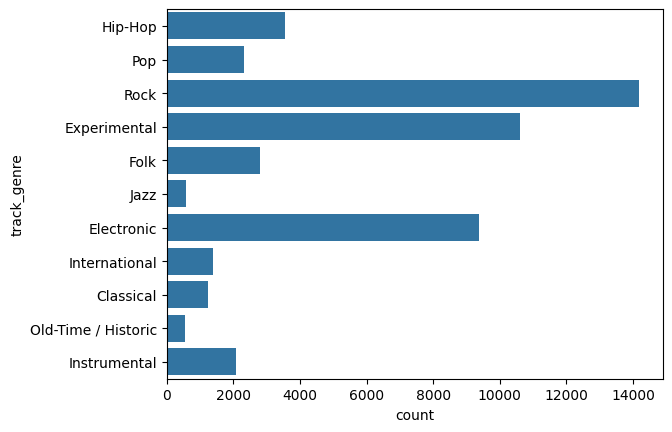

In [10]:
# pobieram
labels = pd.read_csv('labels.csv', dtype = {'track_id': str})

print(f'there is {len(labels.track_genre.unique())} unique genres') # 16 unikalnych gatunków

labels = labels[labels["track_genre"].notna()]  # tam gdzie jest Na musimy usunąć
tracks_per_genre = labels.groupby('track_genre').agg(
    no_tracks = ('track_id', 'size')
)

n = 500

counts = labels["track_genre"].value_counts()
keep = counts[counts > n].index

labels = labels[labels["track_genre"].isin(keep)]

import seaborn as sns

sns.countplot(data = labels, y = 'track_genre')


In [12]:
labels.to_csv('labels.csv', index = False)